# **Noise Models**

**1. Additive Noise (Independent of Pixel Intensity)**

The noise is added to the original image pixels.

Effect: Affects all pixels equally, regardless of their intensity.

Mathematical Model:

g(x,y)=f(x,y)+η(x,y)

g(x,y) → Noisy image.

f(x,y) → Original image.

η(x,y) → Random noise.





**2. Multiplicative Noise (Proportional to Pixel Intensity)**

The noise is multiplied with the original pixel values.

Effect: Affects brighter pixels more than darker pixels.

Mathematical Model:

g(x,y)=f(x,y)+f(x,y)⋅η(x,y)


g(x,y) → Noisy image.

f(x,y) → Original image.

η(x,y) → Noise factor.

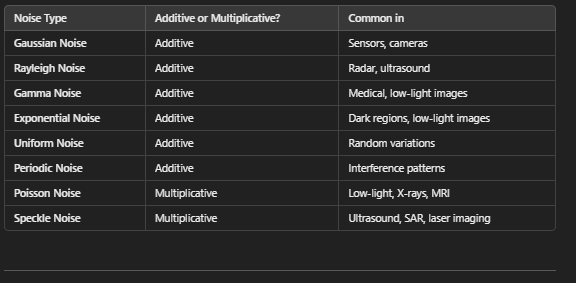

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.ndimage import rank_filter

In [78]:

# Gaussian Noise-->	Random grainy noise over the entire image.
def add_gaussian_noise(image, mean=0, std=1):
    """ Adds Gaussian noise to an image. """
    gauss = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_img = cv2.add(image, gauss)  # Adding noise to image
    return noisy_img



In [79]:
#Rayleigh Noise-->	Hazy or blurred effect, especially in dark areas.
def add_rayleigh_noise(image, scale=25):
    """ Adds Rayleigh noise to an image """
    rayleigh_noise = np.random.rayleigh(scale, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, rayleigh_noise)
    return noisy_image



In [80]:
#Gamma Noise-->	Intensity-dependent bright speckles.
def add_gamma_noise(image, shape=2, scale=50):
    """ Adds Gamma (Speckle) noise to an image """
    gamma_noise = np.random.gamma(shape, scale, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, gamma_noise)
    return noisy_image




In [81]:
# Impulse Noise-->	Sudden black & white pixel corruption (salt-and-pepper effect).

def add_salt_and_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """ Adds salt and pepper noise to an image. """
    noisy_img = image.copy()
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    # Add salt (white) pixels
    for _ in range(num_salt):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_img[y, x] = 255

    # Add pepper (black) pixels
    for _ in range(num_pepper):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_img[y, x] = 0

    return noisy_img



In [82]:
def add_salt_noise(image, salt_prob=0.05):
    """ Adds salt noise to an image. """
    noisy_img = image.copy()
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)


    # Add salt (white) pixels
    for _ in range(num_salt):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_img[y, x] = 255

    return noisy_img


In [83]:
def add_pepper_noise(image, pepper_prob=0.05):
    """ Adds pepper noise to an image. """
    noisy_img = image.copy()
    total_pixels = image.size
    num_pepper = int(total_pixels * pepper_prob)

    # Add pepper (black) pixels
    for _ in range(num_pepper):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_img[y, x] = 0

    return noisy_img


In [84]:
#Uniform Noise-->	Equally distributed speckling effect.
def add_uniform_noise(image, low=-30, high=30):
    """ Adds uniform noise to an image. """
    uniform_noise = np.random.uniform(low, high, image.shape).astype(np.uint8)
    noisy_img = cv2.add(image, uniform_noise)
    return noisy_img


In [85]:
# Exponential Noise-->	Streaky distortions in low-light regions.
def add_exponential_noise(image, scale=50):
    """ Adds Exponential noise to an image """
    exp_noise = np.random.exponential(scale, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, exp_noise)
    return noisy_image


In [86]:
#Periodic Noise-->	Stripes or repetitive artifacts across the image.
def add_periodic_noise(image, frequency=10, amplitude=50):
    """ Adds Periodic noise (sinusoidal pattern) to an image """
    rows, cols = image.shape[:2]
    sinusoidal_noise = (amplitude * np.sin(2 * np.pi * frequency * np.linspace(0, 1, cols))).astype(np.uint8)
    sinusoidal_noise = np.tile(sinusoidal_noise, (rows, 1))

    noisy_image = cv2.add(image, sinusoidal_noise)
    return noisy_image



In [87]:
# Looks grainy and textured, especially in smooth regions,Appears as bright and dark granular patches.
def add_speckle_noise(image, var=0.1):
    """ Adds speckle noise to an image. """
    gauss = np.random.normal(0, var, image.shape)
    noisy_img = image + image * gauss
    return np.clip(noisy_img, 0, 255).astype(np.uint8)



In [88]:
#Looks like grainy dots, especially in bright areas, More visible in dark regions of the image with low photon counts.
def add_poisson_noise(image):
    """ Adds Poisson noise to an image. """
    vals = len(np.unique(image))
    vals = 2 ** np.ceil(np.log2(vals))
    noisy_img = np.random.poisson(image * vals) / float(vals)
    return np.clip(noisy_img, 0, 255).astype(np.uint8)



In [96]:



# Load the generated face image
face_image_path = "/content/checking.jpeg"
image = cv2.imread(face_image_path, cv2.IMREAD_GRAYSCALE)


# Apply different noise models
gaussian_noisy = add_gaussian_noise(image)
salt_pepper_noisy = add_salt_and_pepper_noise(image)
poisson_noisy = add_poisson_noise(image)
speckle_noisy = add_speckle_noise(image)
uniform_noisy = add_uniform_noise(image)
gamma_noisy = add_gamma_noise(image)
rayleigh_noisy = add_rayleigh_noise(image)
exponential_noisy = add_exponential_noise(image)
periodic_noisy = add_periodic_noise(image)
salt_noisy=add_salt_noise(image)
pepper_noisy=add_pepper_noise(image)






AttributeError: 'NoneType' object has no attribute 'shape'

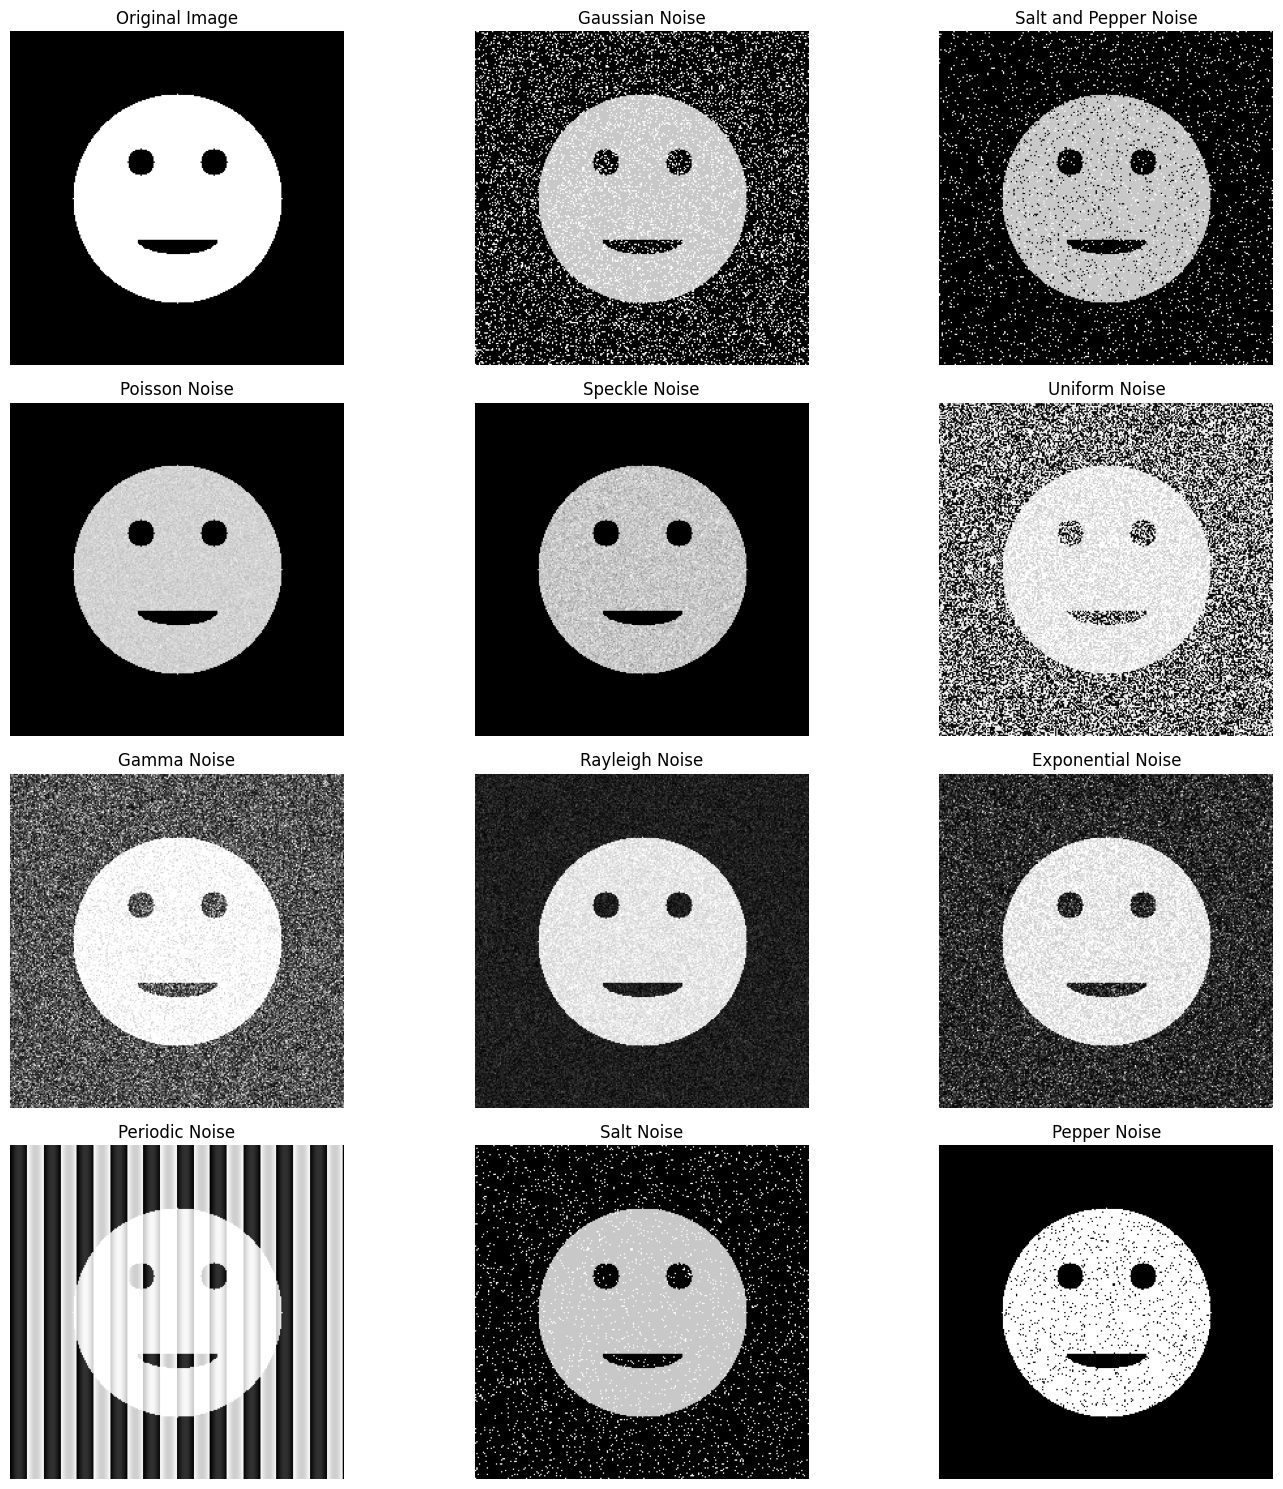

In [ ]:

# Display images
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0,0].axis('off')

axes[0, 1].imshow(gaussian_noisy, cmap='gray')
axes[0, 1].set_title('Gaussian Noise')
axes[0,1].axis('off')

axes[0, 2].imshow(salt_pepper_noisy, cmap='gray')
axes[0, 2].set_title('Salt and Pepper Noise')
axes[0,2].axis('off')

axes[1, 0].imshow(poisson_noisy, cmap='gray')
axes[1,0].set_title('Poisson Noise')
axes[1,0].axis('off')

axes[1, 1].imshow(speckle_noisy, cmap='gray')
axes[1, 1].set_title('Speckle Noise')
axes[1,1].axis('off')

axes[1, 2].imshow(uniform_noisy, cmap='gray')
axes[1, 2].set_title('Uniform Noise')
axes[1,2].axis('off')

axes[2, 0].imshow(gamma_noisy, cmap='gray')
axes[2, 0].set_title('Gamma Noise')
axes[2,0].axis('off')

axes[2, 1].imshow(rayleigh_noisy, cmap='gray')
axes[2,1].set_title('Rayleigh Noise')
axes[2,1].axis('off')

axes[2,2].imshow(exponential_noisy, cmap='gray')
axes[2,2].set_title('Exponential Noise')
axes[2,2].axis('off')

axes[3,0].imshow(periodic_noisy, cmap='gray')
axes[3,0].set_title('Periodic Noise')
axes[3,0].axis('off')


axes[3,1].imshow(salt_noisy, cmap='gray')
axes[3,1].set_title('Salt Noise')
axes[3,1].axis('off')

axes[3,2].imshow(pepper_noisy, cmap='gray')
axes[3,2].set_title('Pepper Noise')
axes[3,2].axis('off')

plt.tight_layout()

plt.show()

# **Image Restoration**

**A. Mean filters:**  

Mean filters are a type of smoothing filter used to reduce noise in an image by averaging pixel values. They are particularly effective for Gaussian noise and uniform noise but may blur edges.

  
 Arithmetic mean filters

 Geometric mean filter

 Harmonic mean filter

 Contraharmonic mean filter

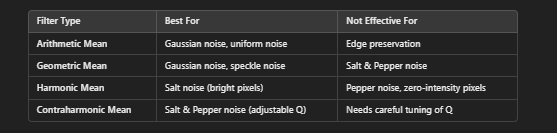

In [90]:
"""
Arithmatic mean filter
Computes the average of all pixel values in a given neighborhood.
Simple and effective for reducing Gaussian noise and uniform noise.
✅ Good for removing Gaussian noise.
❌ Blurs edges and fine details.
"""


def arithmetic_mean_filter(image, kernel_size=3):
    return cv2.blur(image, (kernel_size, kernel_size))



In [91]:
"""
Geometric Mean Filter:

Instead of computing the arithmetic mean, it calculates the geometric mean of neighboring pixels.
Works better than the arithmetic mean for suppressing Gaussian noise and speckle noise.

✅ Preserves edges better than the arithmetic mean.
✅ Effective for multiplicative noise (speckle noise).
❌ Computationally expensive due to multiplication and power operations.
❌ Fails for pixels with zero values (logarithm issues).

"""

def geometric_mean_filter(image, kernel_size=3):
    """Applies Geometric Mean Filter using the formula."""
    image = image.astype(np.float32) + 1e-5  # Avoid zero issues
    log_image = np.log(image)
    filtered = cv2.boxFilter(log_image, ddepth=-1, ksize=(kernel_size, kernel_size))
    return np.exp(filtered).astype(np.uint8)


In [92]:
"""
Harmonic Mean Filter:

Computes the harmonic mean instead of the arithmetic mean.
Works well for Salt noise (bright spots) but not for Pepper noise (dark spots).
✅ Excellent for Salt noise removal.
❌ Fails for Pepper noise (black spots remain).
❌ Not suitable if the image contains zero-intensity pixels.
"""

def harmonic_mean_filter(image, kernel_size=3):
    """Applies Harmonic Mean Filter."""
    image = image.astype(np.float32) + 1e-5  # Avoid division by zero
    inv_image = 1.0 / image
    filtered = cv2.boxFilter(inv_image, ddepth=-1, ksize=(kernel_size, kernel_size))
    return (1.0 / filtered).astype(np.uint8)


In [93]:
"""
Contraharmonic Mean Filter:

Generalizes the Harmonic Mean Filter and is useful for Salt & Pepper noise removal.
Uses a parameter Q to control how the filter reacts to different noise types.

✅ Best for Salt & Pepper noise.
✅ Works for both bright and dark noise by tuning Q
❌ Needs an appropriate choice of Q.

"""

def contraharmonic_mean_filter(image, kernel_size=3, Q=1.5):
    """Applies Contraharmonic Mean Filter. Q > 0 removes salt noise, Q < 0 removes pepper noise."""
    image = image.astype(np.float32) + 1e-5  # Avoid zero issues
    num = cv2.boxFilter(np.power(image, Q + 1), ddepth=-1, ksize=(kernel_size, kernel_size))
    denom = cv2.boxFilter(np.power(image, Q), ddepth=-1, ksize=(kernel_size, kernel_size))
    filtered = num / (denom + 1e-5)  # Avoid division by zero
    return np.clip(filtered, 0, 255).astype(np.uint8)



In [94]:


# Apply Filters
arithmetic_filtered_guassian= arithmetic_mean_filter(gaussian_noisy)
arithmetic_filtered_poisson = arithmetic_mean_filter(poisson_noisy)
arithmetic_filtered_uniform = arithmetic_mean_filter(uniform_noisy)


geometric_filtered_speckle = geometric_mean_filter(speckle_noisy)
geometric_filtered_gamma = geometric_mean_filter(gamma_noisy)


harmonic_filtered_exponential= harmonic_mean_filter(exponential_noisy)
contraharmonic_filtered_salt_pepper = contraharmonic_mean_filter(salt_pepper_noisy, Q=1.5)





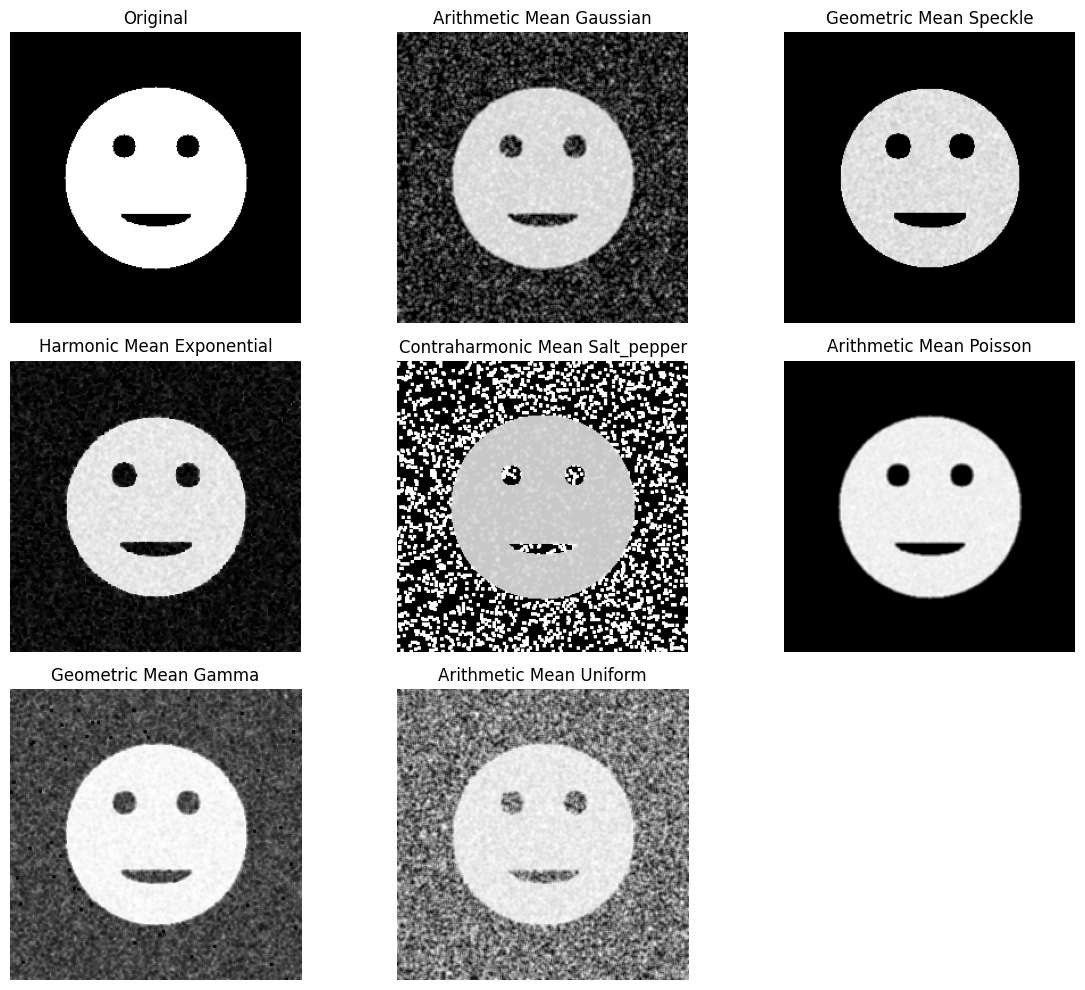

In [95]:
# Display Results
filters = {
    "Original": image,
    "Arithmetic Mean Gaussian": arithmetic_filtered_guassian,
    "Geometric Mean Speckle": geometric_filtered_speckle,
    "Harmonic Mean Exponential": harmonic_filtered_exponential,
    "Contraharmonic Mean Salt_pepper": contraharmonic_filtered_salt_pepper,
    "Arithmetic Mean Poisson": arithmetic_filtered_poisson,
    "Geometric Mean Gamma": geometric_filtered_gamma,
    "Arithmetic Mean Uniform": arithmetic_filtered_uniform
}

plt.figure(figsize=(12, 10))
for i, (title, img) in enumerate(filters.items()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

**2. Order-Statistics Filters:**

Order-statistic filters are non-linear spatial filters used in image restoration to reduce noise while preserving edges. Instead of computing the average like mean filters, they sort pixel values in a neighborhood and select specific values based on their statistical rank.

Median filters

Max and min filters

Midpoint filter

Alpha-trimmed mean filter

In [ ]:
"""
Median filter
Selects the median value from the sorted pixel values in a neighborhood.
✅ Salt-and-pepper noise removal
✅ Preserves edges better than mean filters
❌ May not work well for Gaussian noise
"""

def median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)

In [ ]:
"""
Max Filter
Selects the maximum value from the neighborhood.
✅ Pepper noise removal (dark pixels)
✅ Enhancing bright details
❌ Can intensify bright noise
"""

def max_filter(image, kernel_size=3):
    return rank_filter(image, size=kernel_size, rank=-1)


In [ ]:
"""
Min Filter
Selects the minimum value from the neighborhood.

✅ Salt noise removal (bright pixels)
✅ Enhancing dark areas
❌ Can darken images excessively
"""

def min_filter(image, kernel_size=3):
    return rank_filter(image, size=kernel_size, rank=0)

In [ ]:
"""
Midpoint Filter
Averages the minimum and maximum pixel values.

✅ Gaussian and uniform noise reduction
✅ Preserves edges better than mean filters
❌ Not effective for impulse noise
"""

def midpoint_filter(image, kernel_size=3):
    max_img = max_filter(image, kernel_size)
    min_img = min_filter(image, kernel_size)
    return ((max_img + min_img) / 2).astype(np.uint8)


In [ ]:
# Apply Filters
median_filtered_salt_pepper = median_filter(salt_pepper_noisy)
max_filtered_pepper = max_filter(pepper_noisy)
min_filtered_salt = min_filter(salt_noisy)
midpoint_filtered_uniform = midpoint_filter(uniform_noisy)
midpoint_filtered_guassian = midpoint_filter(gaussian_noisy)


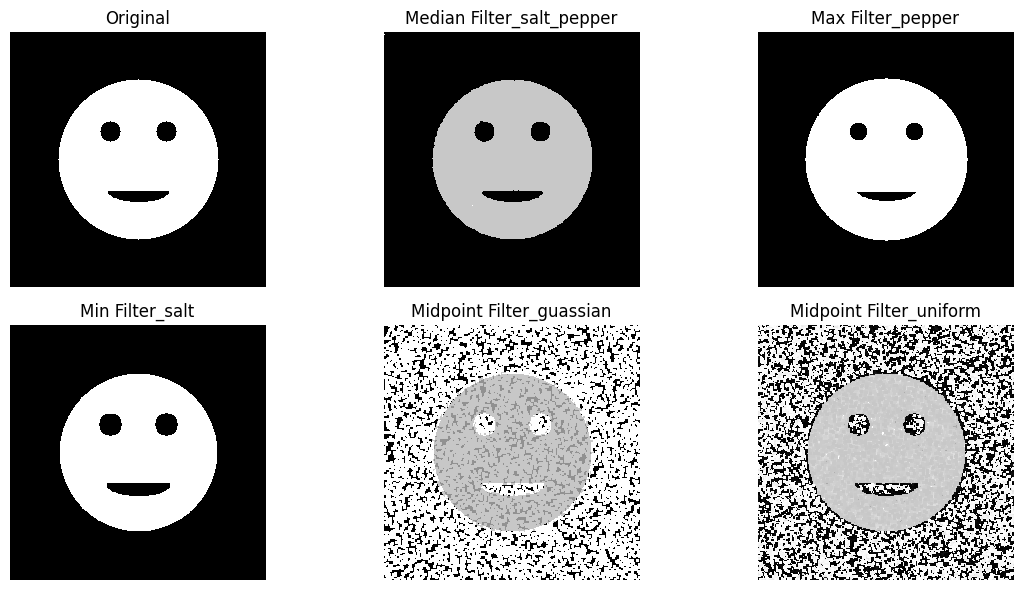

In [ ]:
# Display Results
filters = {
    "Original": image,
    "Median Filter_salt_pepper": median_filtered_salt_pepper,
    "Max Filter_pepper": max_filtered_pepper,
    "Min Filter_salt": min_filtered_salt,
    "Midpoint Filter_guassian": midpoint_filtered_guassian,
    "Midpoint Filter_uniform": midpoint_filtered_uniform


}

plt.figure(figsize=(12, 6))
for i, (title, img) in enumerate(filters.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Conclusion**

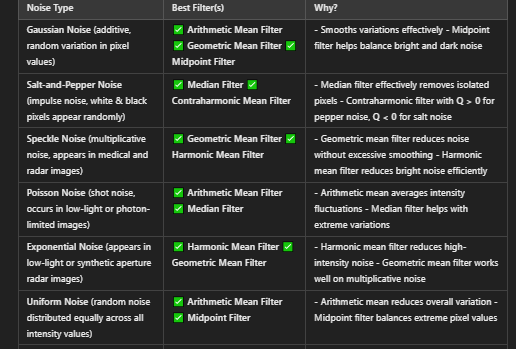                

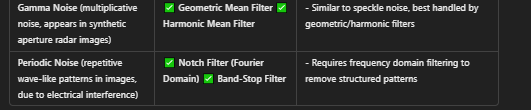

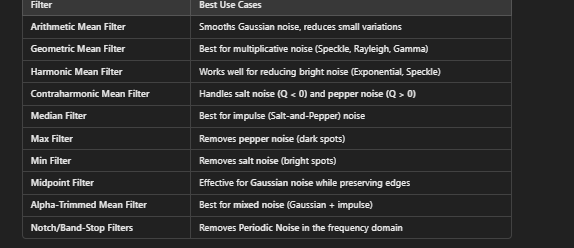